Energy Verification (20 seconds, dt=0.05)
[Forward Euler] Energy is NOT conserved. (Deviation: 30.0419 J/kg)
[Backward Euler] Energy is conserved. (Deviation: 0.3920 J/kg)


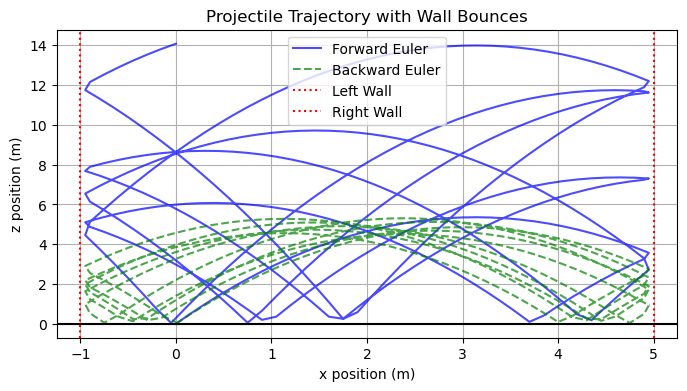

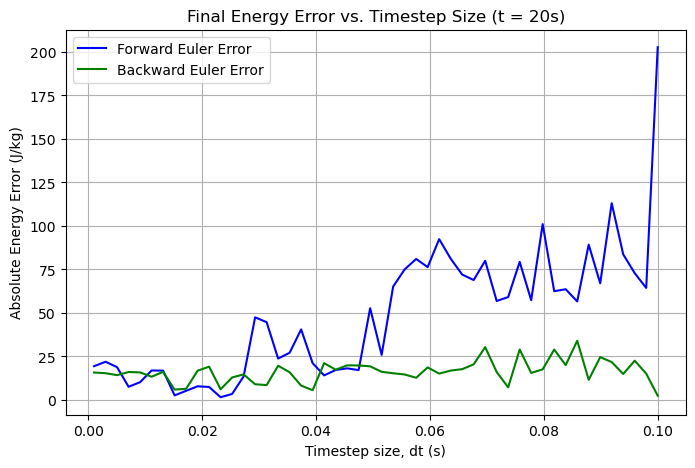

In [1]:
import numpy as np
import matplotlib.pyplot as plt

g=-9.8
xpos, zpos = 0,0
xvel, zvel = 3, 10

def mechanical_energy(pos, vel):
    return 0.5*(vel[0]**2+vel[1]**2-g*pos[1])

def check_energy_conservation(energy_list, method_name, tolerance=1.0):
    initial_energy = energy_list[0]
    final_energy = energy_list[-1]
    deviation = abs(final_energy - initial_energy)
    
    if deviation < tolerance:
        print(f"[{method_name}] Energy is conserved. (Deviation: {deviation:.4f} J/kg)")
    else:
        print(f"[{method_name}] Energy is NOT conserved. (Deviation: {deviation:.4f} J/kg)")

def move_with_bounce_forward(pos, vel, dt):
    next_pos = [pos[0] + vel[0] * dt, pos[1] + vel[1] * dt]
    next_vel = [vel[0], vel[1] + g * dt]
    
    # Ground Bounce
    if next_pos[1] < 0:
        next_pos[1] = -next_pos[1]  
        next_vel[1] = -next_vel[1]  
        
    # Wall Bounce (x = -1)
    if next_pos[0] < -1:
        next_pos[0] = -1 - (next_pos[0] - (-1))
        next_vel[0] = -next_vel[0]
        
    # Wall Bounce (x = 5)
    elif next_pos[0] > 5:
        next_pos[0] = 5 - (next_pos[0] - 5)
        next_vel[0] = -next_vel[0]
        
    return next_pos, next_vel

def move_with_bounce_backward(pos, vel, dt):

    next_vel = [vel[0], vel[1] + g * dt]

    next_pos = [pos[0] + next_vel[0] * dt, pos[1] + next_vel[1] * dt]
    

    if next_pos[1] < 0:
        next_pos[1] = -next_pos[1]
        next_vel[1] = -next_vel[1]
        
    if next_pos[0] < -1:
        next_pos[0] = -1 - (next_pos[0] - (-1))
        next_vel[0] = -next_vel[0]
        
    elif next_pos[0] > 5:
        next_pos[0] = 5 - (next_pos[0] - 5)
        next_vel[0] = -next_vel[0]
        
    return next_pos, next_vel

dt = 0.05
t_range = np.arange(0, 20 + dt, dt)

pos_f_list, vel_f_list, energy_f_list = [[xpos, zpos]], [[xvel, zvel]], [mechanical_energy([xpos, zpos], [xvel, zvel])]
pos_b_list, vel_b_list, energy_b_list = [[xpos, zpos]], [[xvel, zvel]], [mechanical_energy([xpos, zpos], [xvel, zvel])]

for t in t_range[:-1]:
    # Forward Euler Step
    pos_f, vel_f = move_with_bounce_forward(pos_f_list[-1], vel_f_list[-1], dt)
    pos_f_list.append(pos_f)
    vel_f_list.append(vel_f)
    energy_f_list.append(mechanical_energy(pos_f, vel_f))
    
    # Backward Euler Step
    pos_b, vel_b = move_with_bounce_backward(pos_b_list[-1], vel_b_list[-1], dt)
    pos_b_list.append(pos_b)
    vel_b_list.append(vel_b)
    energy_b_list.append(mechanical_energy(pos_b, vel_b))

print("Energy Verification (20 seconds, dt=0.05)")
check_energy_conservation(energy_f_list, "Forward Euler")
check_energy_conservation(energy_b_list, "Backward Euler")

plt.figure(figsize=(8, 4))    
plt.plot([p[0] for p in pos_f_list], [p[1] for p in pos_f_list], 'b-', alpha=0.7, label='Forward Euler')
plt.plot([p[0] for p in pos_b_list], [p[1] for p in pos_b_list], 'g--', alpha=0.7, label='Backward Euler')
plt.axvline(x=-1, color='r', linestyle=':', label='Left Wall')
plt.axvline(x=5, color='r', linestyle=':', label='Right Wall')
plt.axhline(y=0, color='k', linestyle='-')
plt.title('Projectile Trajectory with Wall Bounces')
plt.xlabel('x position (m)')
plt.ylabel('z position (m)')
plt.legend()
plt.grid(True)
plt.show()

dt_values = np.linspace(0.001, 0.1, 50)
error_f = []
error_b = []

initial_energy = mechanical_energy([xpos, zpos], [xvel, zvel])

for current_dt in dt_values:

    p_f, v_f = [xpos, zpos], [xvel, zvel]
    p_b, v_b = [xpos, zpos], [xvel, zvel]
    

    steps = int(20 / current_dt)
    
    for _ in range(steps):
        p_f, v_f = move_with_bounce_forward(p_f, v_f, current_dt)
        p_b, v_b = move_with_bounce_backward(p_b, v_b, current_dt)
        

    final_e_f = mechanical_energy(p_f, v_f)
    final_e_b = mechanical_energy(p_b, v_b)
    
    error_f.append(abs(final_e_f - initial_energy))
    error_b.append(abs(final_e_b - initial_energy))

plt.figure(figsize=(8, 5))
plt.plot(dt_values, error_f, 'b-', label='Forward Euler Error')
plt.plot(dt_values, error_b, 'g-', label='Backward Euler Error')
plt.title('Final Energy Error vs. Timestep Size (t = 20s)')
plt.xlabel('Timestep size, dt (s)')
plt.ylabel('Absolute Energy Error (J/kg)')
plt.legend()
plt.grid(True)
plt.show()